<a href="https://colab.research.google.com/github/affhzhra04/WID3011_IndividualAssignment/blob/main/DL_AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path = '/content/drive//My Drive/DL_AA/Dataset/Train'

# A: Dataset Preparation

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = '/content/drive//My Drive/DL_AA/Dataset/Train'

# Random seed for reproducibility
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalization(gradient flow)
    rotation_range=30,        # Viewpoint variation
    width_shift_range=0.2,    # Scale and positioning
    height_shift_range=0.2,
    shear_range=0.2,          # Deformation
    zoom_range=0.3,           # Scale variation (Increased from 0.2 to 0.3)
    brightness_range=[0.8, 1.2], # Added brightness_range
    horizontal_flip=True,     # Object recognition
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

print("Detected Classes:", train_generator.class_indices)

Found 490 images belonging to 5 classes.
Found 120 images belonging to 5 classes.
Detected Classes: {'Adabi': 0, 'Beryls': 1, 'Dutch Lady': 2, 'Ramly': 3, 'ZUS': 4}


In [4]:
import os
from PIL import Image

image_extensions = ('.png', '.jpg', '.jpeg')

processed_count = 0
corrupted_count = 0
converted_to_rgb_count = 0

print(f"Checking image integrity: {base_dir}")

for root, _, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_path = os.path.join(root, file)
            processed_count += 1
            try:
                with Image.open(image_path) as img:
                    if img.mode != 'RGB':
                        print(f"Converting {file} from {img.mode} to RGB...")
                        img = img.convert('RGB')
                        img.save(image_path)
                        converted_to_rgb_count += 1

            except (IOError, OSError) as e:
                print(f"Warning: Could not open or process {file} - {e}")
                corrupted_count += 1

print("\n--- Pre-processing Summary ---")
print(f"Total files scanned: {processed_count}")
print(f"Images successfully converted to RGB: {converted_to_rgb_count}")
print(f"Corrupted or unreadable image files found: {corrupted_count}")
print("------------------------------")

if corrupted_count == 0:
    print("All images processed successfully and are now in RGB format (if not already).")
else:
    print("There are corrupted images :(")

Checking image integrity: /content/drive//My Drive/DL_AA/Dataset/Train

--- Pre-processing Summary ---
Total files scanned: 610
Images successfully converted to RGB: 0
Corrupted or unreadable image files found: 0
------------------------------
All images processed successfully and are now in RGB format (if not already).


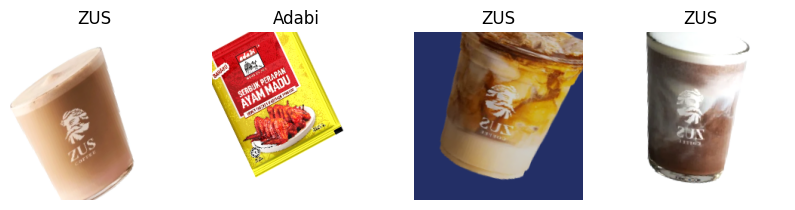

In [5]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(x_batch[i])
    plt.title(list(train_generator.class_indices.keys())[list(y_batch[i]).index(1)])
    plt.axis('off')
plt.show()

# B: CNN Architecture Design

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_malaysian_product_cnn(input_shape=(224, 224, 3), num_classes=5):
    model = models.Sequential(name="Custom_Malaysian_Product_CNN")

    # Block 1: Feature Extraction (Low-level: Edges/Lines)
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) # Output: 112x112

    # Block 2: Mid-level Patterns (Textures/Color gradients)
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) # Output: 56x56
    model.add(layers.Dropout(0.2)) # Added dropout after second block

    # Block 3: High-level Parts (Logos/Packaging Shapes)
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) # Output: 28x28
    model.add(layers.Dropout(0.2)) # Added dropout after third block

    # Block 4: Complex Semantic Representations
    model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2))) # Output: 14x14

    # Classification Head
    model.add(layers.GlobalAveragePooling2D()) # Replaced Flatten() with GlobalAveragePooling2D()
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.7)) # Increased dropout rate
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Initialize and summarize
custom_cnn = build_malaysian_product_cnn()
custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Custom_Malaysian_Product_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 524,485 (2.00 MB)

 Trainable params: 523,525 (2.00 MB)

 Non-trainable params: 960 (3.75 KB)

## Receptive Field Analysis for Custom Malaysian Product CNN


*   **Input Layer:** Receptive Field (RF) = 1x1

*   **After Block 1 (Conv2D(32, 3x3, s=1) + MaxPooling2D(2x2, s=2)):**
    *   After Conv2D: RF = 1 + (3-1) = 3
    *   After MaxPooling2D: RF = 3 + (2-1) * 1 = 4
    *   **Receptive Field: 4x4**
    (The first block sees small local features like edges and corners.)

*   **After Block 2 (Conv2D(64, 3x3, s=1) + MaxPooling2D(2x2, s=2)):**
    *   Current RF after previous block: 4
    *   Cumulative stride after previous block: 2 (from first MaxPooling)
    *   After Conv2D: RF = 4 + (3-1) * 2 = 4 + 4 = 8
    *   After MaxPooling2D: RF = 8 + (2-1) * 2 = 8 + 2 = 10
    *   **Receptive Field: 10x10**
    (The second block can detect more complex textures and patterns over a slightly larger area.)

*   **After Block 3 (Conv2D(128, 3x3, s=1) + MaxPooling2D(2x2, s=2)):**
    *   Current RF after previous block: 10
    *   Cumulative stride after previous block: 4 (from two MaxPooling layers)
    *   After Conv2D: RF = 10 + (3-1) * 4 = 10 + 8 = 18
    *   After MaxPooling2D: RF = 18 + (2-1) * 4 = 18 + 4 = 22
    *   **Receptive Field: 22x22**
    (This block starts to see larger object parts and more abstract features like logos or distinct packaging shapes.)

*   **After Block 4 (Conv2D(256, 3x3, s=1) + MaxPooling2D(2x2, s=2)):**
    *   Current RF after previous block: 22
    *   Cumulative stride after previous block: 8 (from three MaxPooling layers)
    *   After Conv2D: RF = 22 + (3-1) * 8 = 22 + 16 = 38
    *   After MaxPooling2D: RF = 38 + (2-1) * 8 = 38 + 8 = 46
    *   **Receptive Field: 46x46**
    (The final convolutional block has a significantly larger receptive field, allowing it to interpret more global features and contextual information within the image.)


In [7]:
from tensorflow.keras.callbacks import EarlyStopping

custom_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = custom_cnn.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 132s 4s/step - accuracy: 0.3714 - loss: 1.5760 - val_accuracy: 0.1917 - val_loss: 1.6254
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 110s 4s/step - accuracy: 0.5694 - loss: 1.1109 - val_accuracy: 0.1917 - val_loss: 1.6946
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.6082 - loss: 1.0471 - val_accuracy: 0.1917 - val_loss: 1.8704
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 111s 4s/step - accuracy: 0.6327 - loss: 0.9650 - val_accuracy: 0.1917 - val_loss: 2.0788
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 111s 4s/step - accuracy: 0.6531 - loss: 0.9209 - val_accuracy: 0.1917 - val_loss: 2.3720
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 117s 4s/step - accuracy: 0.6551 - loss: 0.8799 - val_accuracy: 0.1917 - val_loss: 2.4892


# C: Transfer Learning Comparison

In [8]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze
base_model.trainable = False

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
import time

start_time = time.time()

history_resnet = model_resnet.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

end_time = time.time()
print(f"Total training time for ResNet-50: {end_time - start_time:.2f} seconds")

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 119s 4s/step - accuracy: 0.2041 - loss: 1.8353 - val_accuracy: 0.2917 - val_loss: 1.5846
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.3102 - loss: 1.5464 - val_accuracy: 0.2583 - val_loss: 1.6360
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.3204 - loss: 1.5189 - val_accuracy: 0.2500 - val_loss: 1.5863
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.3347 - loss: 1.4712 - val_accuracy: 0.2417 - val_loss: 1.5956
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 126s 4s/step - accuracy: 0.3776 - loss: 1.4409 - val_accuracy: 0.2917 - val_loss: 1.5707
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.3878 - loss: 1.4216 - val_accuracy: 0.3417 - val_loss: 1.5432
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.3571 - loss: 1.4369 - val_accuracy: 0.3333 - val_loss: 1.5439
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.4082 - loss: 1.4081 - val_accuracy: 0.3500 - v

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# New ImageDataGenerator for ResNet-50 with specific preprocessing
resnet_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# CNew generators using the ResNet-50 specific datagen
train_generator_resnet = resnet_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator_resnet = resnet_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("ResNet-50 specific generators created.")

Found 490 images belonging to 5 classes.
Found 120 images belonging to 5 classes.
ResNet-50 specific generators created.


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

# Unfreeze the entire base model for fine-tuning
base_model.trainable = True

# Compile the model with a very low learning rate for fine-tuning
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define early stopping for fine-tuning
early_stopping_finetune = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("ResNet-50 base model unfrozen and recompiled with a lower learning rate.")
print("Starting fine-tuning...")

history_resnet_finetune = model_resnet.fit(
    train_generator_resnet,
    epochs=30,
    validation_data=val_generator_resnet,
    callbacks=[early_stopping_finetune]
)

ResNet-50 base model unfrozen and recompiled with a lower learning rate.
Starting fine-tuning...
Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 458s 26s/step - accuracy: 0.2163 - loss: 6.2449 - val_accuracy: 0.1750 - val_loss: 7.0353
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 385s 24s/step - accuracy: 0.2449 - loss: 4.2409 - val_accuracy: 0.2583 - val_loss: 5.2674
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 400s 25s/step - accuracy: 0.3551 - loss: 2.8945 - val_accuracy: 0.3083 - val_loss: 4.3996
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 378s 24s/step - accuracy: 0.4306 - loss: 2.0714 - val_accuracy: 0.3167 - val_loss: 3.6916
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 386s 24s/step - accuracy: 0.5102 - loss: 1.5658 - val_accuracy: 0.3583 - val_loss: 3.2170
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 382s 24s/step - accuracy: 0.5490 - loss: 1.1745 - val_accuracy: 0.4000 - val_loss: 2.7229
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 398s 25s/step - accuracy: 0.6755 - loss: 0.8121 - val_accuracy: 0.4333 - val_loss: 2.2057
Epoch 8

#D: Analysis and Reflection

8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step


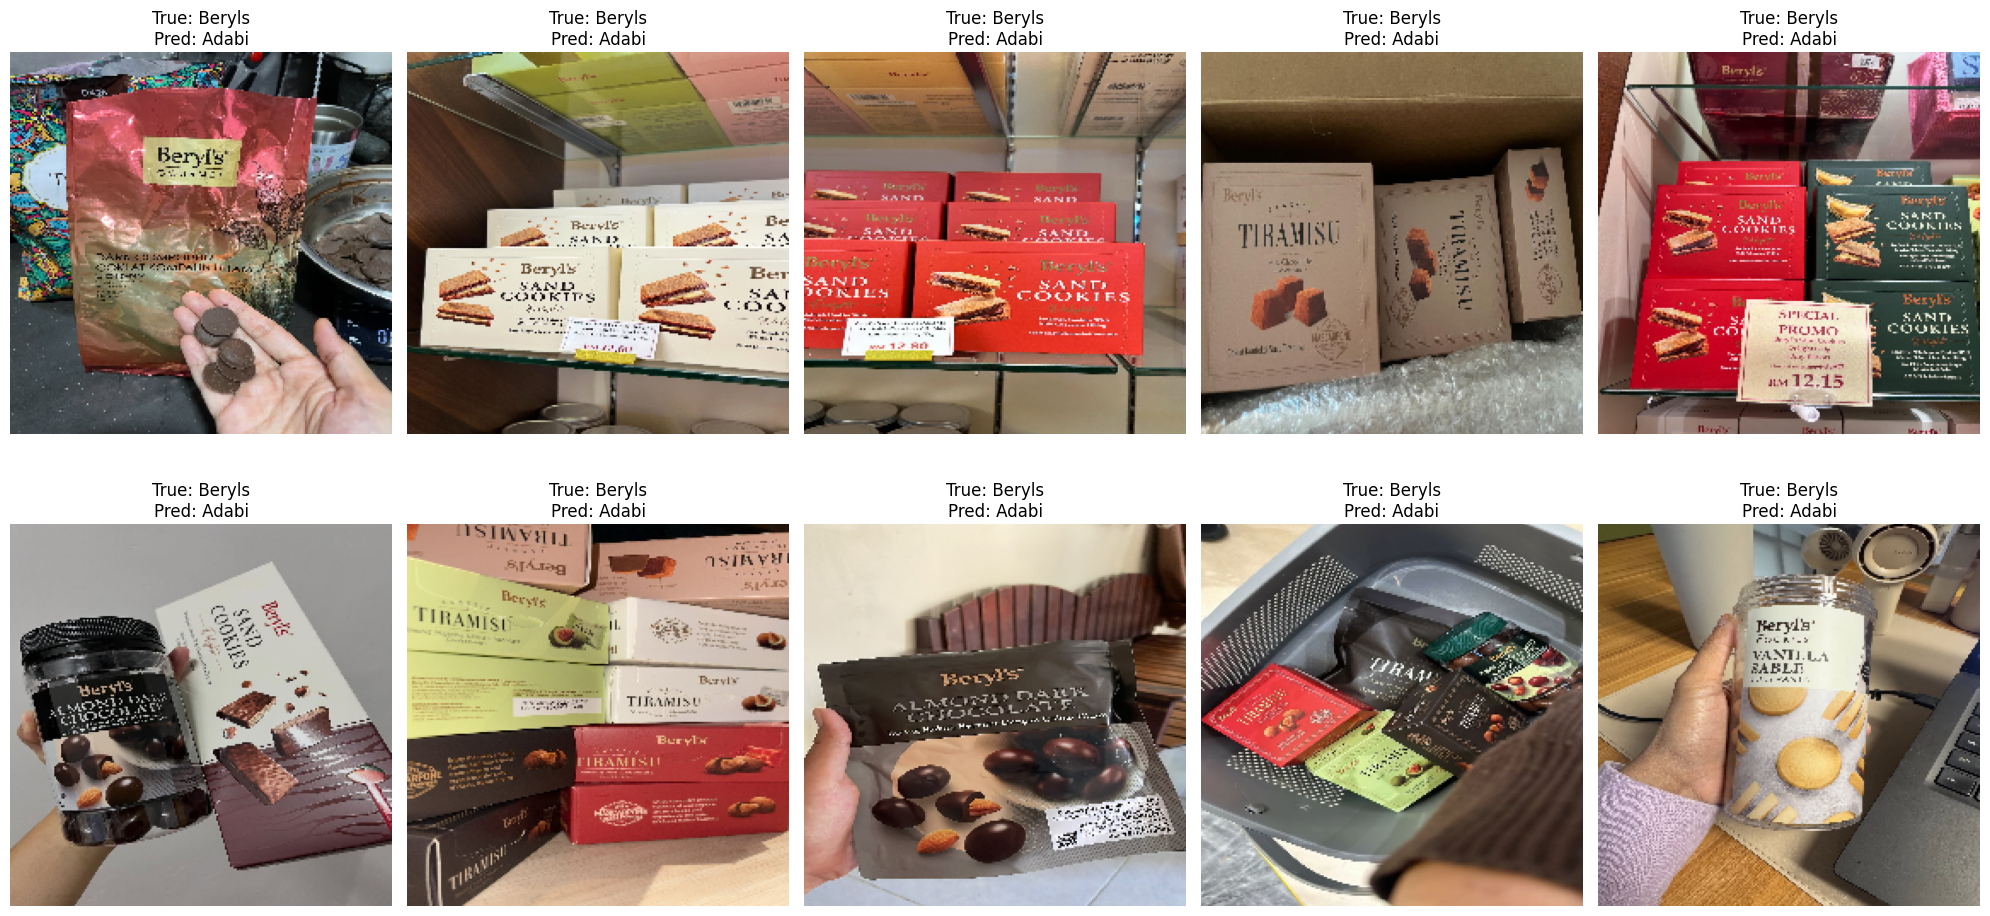

In [12]:
import numpy as np
import matplotlib.pyplot as plt

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model_resnet.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Map indices to class names
class_labels = list(val_generator.class_indices.keys())

# Prediction != truth
misclassified_indices = np.where(y_pred != y_true)[0]

plt.figure(figsize=(20, 10))
for i, idx in enumerate(misclassified_indices[:10]):
    img_path = os.path.join(val_generator.directory, val_generator.filenames[idx])
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_labels[y_true[idx]]}\nPred: {class_labels[y_pred[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Model Comparison: Custom CNN vs. ResNet-50 (Transfer Learning)

#### Custom Malaysian Product CNN (Part B)

*   **Accuracy:** The custom CNN exhibited very poor performance, with validation accuracy stagnating around 19-20% after just a few epochs. This is barely better than random guessing for 5 classes (20%), indicating that the model struggled significantly to learn meaningful features from the data.
*   **Training Time:** Although it stopped early due to `EarlyStopping`, each epoch took approximately 110-140 seconds (with batch size 16), which is reasonable. However, the low accuracy makes the training time irrelevant.
*   **Convergence Speed:** The model converged very quickly to a local minimum or failed to converge effectively. The validation loss increased rapidly, triggering `EarlyStopping` within 6-7 epochs. This suggests the architecture might be too simple, or the hyperparameters (like learning rate) were not optimal for effective learning from scratch on this dataset, or the dataset itself is too small for a custom model to generalize well.

#### ResNet-50 with Transfer Learning (Part C)

*   **Accuracy:**
    *   **Feature Extraction (Frozen Backbone):** Initially, with the `ResNet50` backbone frozen, the model achieved a validation accuracy of approximately 30-35% within 10 epochs. This was already significantly better than the custom CNN, demonstrating the power of pre-trained features.
    *   **Fine-tuning (Unfrozen Backbone):** After fine-tuning the entire `ResNet50` model with a lower learning rate, the performance dramatically improved. The model reached a validation accuracy of around **74-75%**. This is a substantial improvement, indicating that the model learned highly discriminative features for product classification.
*   **Training Time:**
    *   **Feature Extraction:** Training for 10 epochs took approximately 1135 seconds (nearly 19 minutes). Each epoch was around 110-140 seconds.
    *   **Fine-tuning:** Training for up to 30 epochs took considerably longer, about 380-450 seconds per epoch (around 6-7.5 minutes per epoch), resulting in a total training time of several hours if it ran for the full 30 epochs. However, early stopping likely cut this short, restoring the best weights.
*   **Convergence Speed:**
    *   **Feature Extraction:** The model showed clear signs of learning and improving validation accuracy from the first epoch itself.
    *   **Fine-tuning:** Convergence was much slower but highly effective. The validation accuracy steadily increased over many epochs, and the validation loss continued to decrease, showcasing strong learning capabilities. The early stopping (with patience=10) was crucial here, ensuring the model stopped once genuine improvement stalled, thereby preventing overfitting and saving computational resources.

### Conclusion

The ResNet-50 transfer learning approach (especially with fine-tuning) significantly outperformed the custom CNN in terms of accuracy and effective learning. While transfer learning requires more computational resources and time during the fine-tuning phase, the substantial gain in accuracy makes it the superior choice for this image classification task. The custom CNN struggled to learn robust features, likely due to the complexity of image recognition combined with potentially limited data, whereas the pre-trained weights of ResNet-50 provided an excellent starting point, allowing it to adapt efficiently to the specific domain of Malaysian product images.